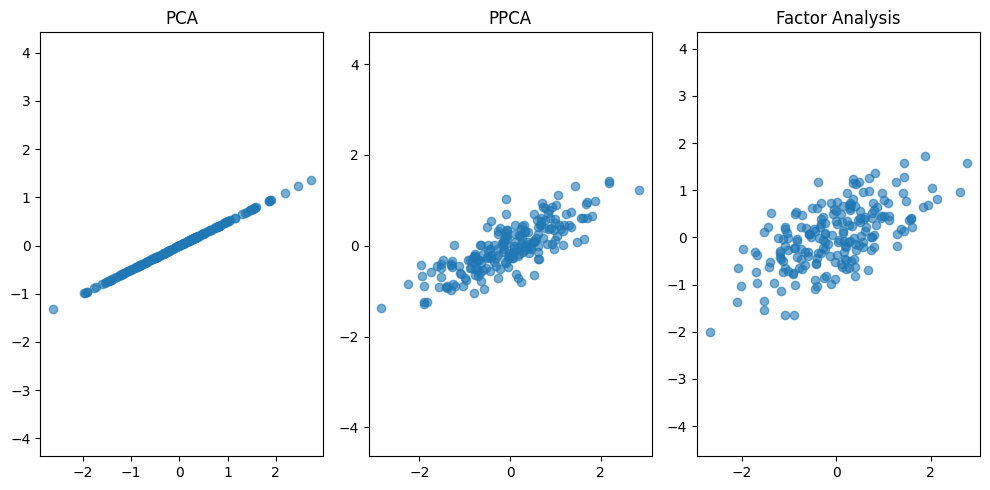

In [ ]:
# Re-import libraries due to kernel reset
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Latent dimension
d = 1
# Observed dimension
D = 2
# Number of samples
n_samples = 200

# Latent variable h ~ N(0, I)
h = np.random.randn(n_samples, d)

# Noise terms
sigma = 0.3
chi1 = np.random.randn(n_samples, D) * sigma  # isotropic for PPCA
chi2 = np.random.randn(n_samples, D) * np.array([0.1, 0.5])  # anisotropic for FA

# Weight matrix W (D x d) and bias b (D)
W = np.array([[1.0], [0.5]])
b = np.array([0.0, 0.0])

# PCA: x = Wh + b
x_pca = h @ W.T + b

# PPCA: x = Wh + b + sigma * z
x_ppca = h @ W.T + b + chi1

# FA: x = Wh + b + chi (with different variances per dimension)
x_fa = h @ W.T + b + chi2

# Plotting
plt.figure(figsize=(10, 5))

plt.subplot(1, 3, 1)
plt.title("PCA")
plt.scatter(x_pca[:, 0], x_pca[:, 1], alpha=0.6)
plt.axis('equal')

plt.subplot(1, 3, 2)
plt.title("PPCA")
plt.scatter(x_ppca[:, 0], x_ppca[:, 1], alpha=0.6)
plt.axis('equal')

plt.subplot(1, 3, 3)
plt.title("Factor Analysis")
plt.scatter(x_fa[:, 0], x_fa[:, 1], alpha=0.6)
plt.axis('equal')

plt.tight_layout()
plt.show()

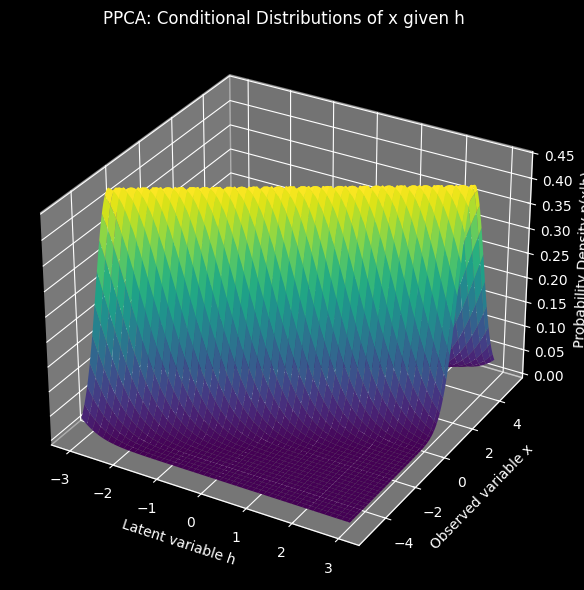

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from mpl_toolkits.mplot3d import Axes3D

# PPCA parameters
W = 1.0       # Weight (maps latent to observed)
mu = 0.0      # Mean of x
sigma = 0.9   # Noise std

# Grid values
h_vals = np.linspace(-3, 3, 100)   # latent values
x_vals = np.linspace(-5, 5, 200)   # observed values

# Create a meshgrid for plotting
H, X = np.meshgrid(h_vals, x_vals)

# Compute mean of x given h: E[x | h] = W h + mu
mean_x_given_h = W * H + mu

# Compute PDF values for each (h, x)
Z = norm.pdf(X, loc=mean_x_given_h, scale=sigma)

# Plot
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(H, X, Z, cmap='viridis', linewidth=0, antialiased=True)

# Labels
ax.set_xlabel('Latent variable h')
ax.set_ylabel('Observed variable x')
ax.set_zlabel('Probability Density p(x|h)')
ax.set_title('PPCA: Conditional Distributions of x given h')

plt.tight_layout()
plt.show()

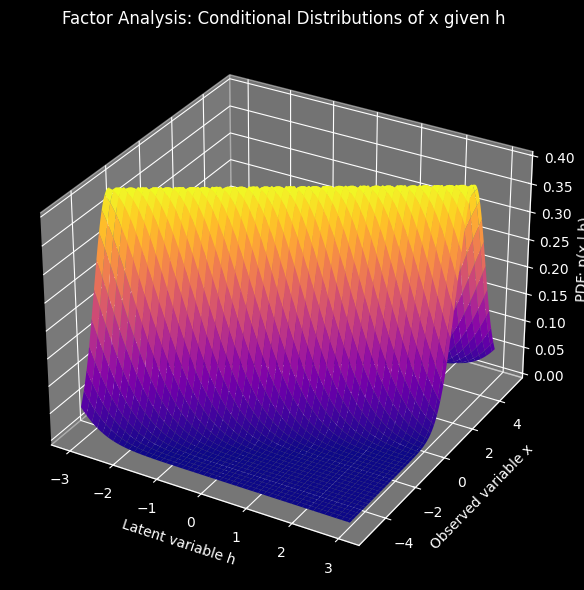

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from mpl_toolkits.mplot3d import Axes3D

# Factor analysis parameters
W = 1.0       # Factor loading
mu = 0.0      # Mean
psi = 1.0     # Non-isotropic noise variance (not sigma^2 like in PPCA)

# Grid for latent h and observed x
h_vals = np.linspace(-3, 3, 100)
x_vals = np.linspace(-5, 5, 200)

# Create meshgrid
H, X = np.meshgrid(h_vals, x_vals)

# Conditional mean of x given h
mean_x_given_h = W * H + mu

# Conditional PDF of x given h
Z = norm.pdf(X, loc=mean_x_given_h, scale=np.sqrt(psi))

# Plotting
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(H, X, Z, cmap='plasma', linewidth=0, antialiased=True)

# Labels
ax.set_xlabel('Latent variable h')
ax.set_ylabel('Observed variable x')
ax.set_zlabel('PDF: p(x | h)')
ax.set_title('Factor Analysis: Conditional Distributions of x given h')

plt.tight_layout()
plt.show()

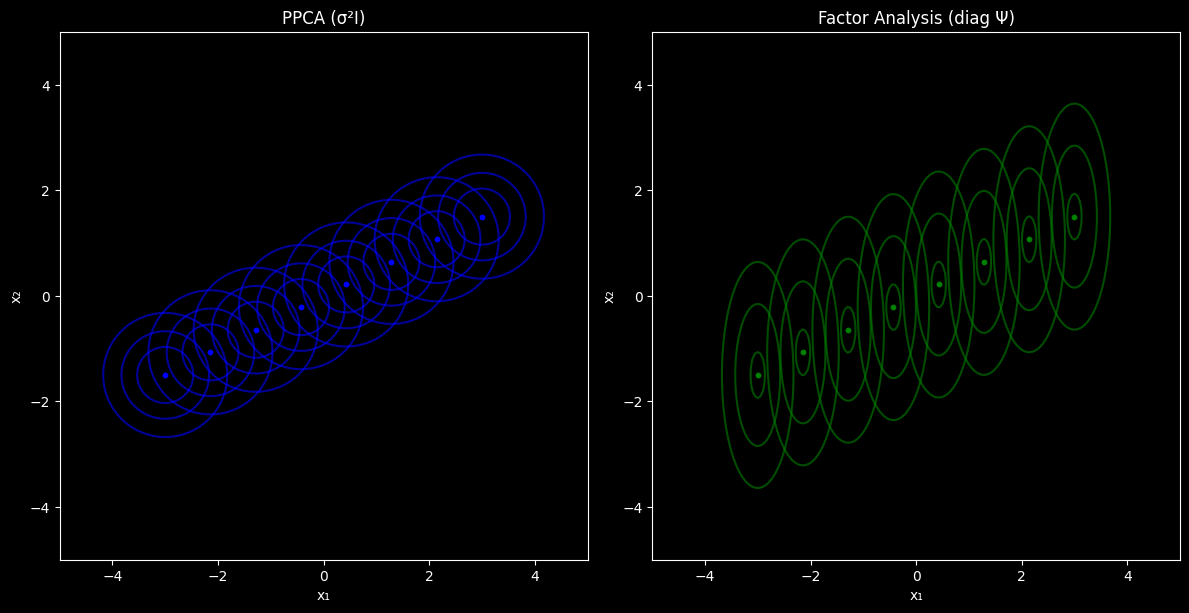

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

def plot_contours(ax, model_name, W, mu, cov_fn, color='blue'):
    h_vals = np.linspace(-3, 3, 8)
    for h in h_vals:
        mean = W @ np.array([h]) + mu  # 2D mean
        cov = cov_fn()  # 2x2 covariance matrix
        rv = multivariate_normal(mean=mean, cov=cov)

        # Grid for contour plot
        x, y = np.mgrid[-5:5:.05, -5:5:.05]
        pos = np.dstack((x, y))
        z = rv.pdf(pos)

        ax.contour(x, y, z, levels=3, alpha=0.6, colors=color)
        ax.scatter(*mean, color=color, s=10)

    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_aspect('equal')
    ax.set_title(model_name)

# Parameters
W = np.array([[1.0], [0.5]])   # maps scalar h to 2D x
mu = np.array([0.0, 0.0])

# Covariance functions
def ppca_cov():
    return np.eye(2) * 0.5  # isotropic

def fa_cov():
    return np.diag([0.2, 2.0])  # anisotropic

# Plot both side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

plot_contours(axes[0], 'PPCA (σ²I)', W, mu, ppca_cov, color='blue')
plot_contours(axes[1], 'Factor Analysis (diag Ψ)', W, mu, fa_cov, color='green')

for ax in axes:
    ax.set_xlabel('x₁')
    ax.set_ylabel('x₂')

plt.tight_layout()
plt.show()

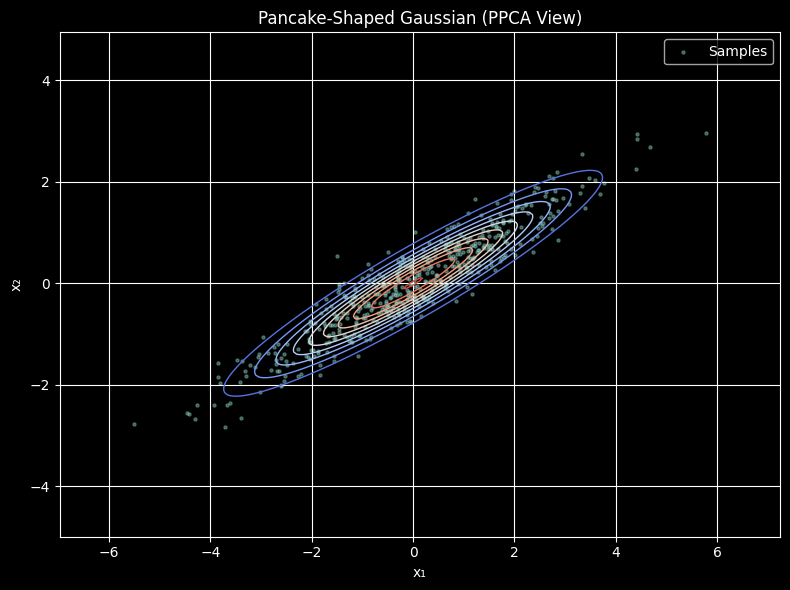

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Define PPCA-like Gaussian parameters
mean = np.array([0.0, 0.0])
eigenvalues = np.array([4.0, 0.1])  # Large along 1st, small along 2nd
theta = np.radians(30)             # Rotate ellipse 30 degrees

# Rotation matrix
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])

# Covariance matrix: R * Λ * R^T
Lambda = np.diag(eigenvalues)
cov = R @ Lambda @ R.T

# Generate samples
samples = np.random.multivariate_normal(mean, cov, size=500)

# Grid for contour plotting
x, y = np.mgrid[-5:5:.05, -5:5:.05]
pos = np.dstack((x, y))
rv = multivariate_normal(mean, cov)
z = rv.pdf(pos)

# Plot
plt.figure(figsize=(8, 6))
plt.contour(x, y, z, levels=10, cmap='coolwarm', linewidths=1)
plt.scatter(samples[:, 0], samples[:, 1], s=5, alpha=0.4, label='Samples')
plt.title('Pancake-Shaped Gaussian (PPCA View)')
plt.xlabel('x₁')
plt.ylabel('x₂')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

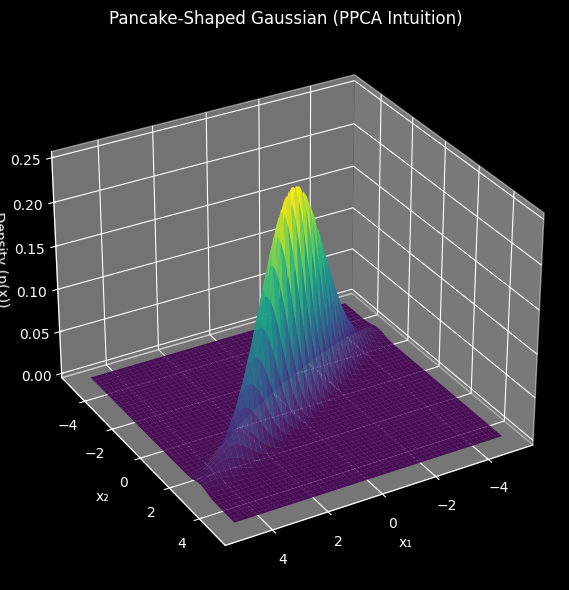

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from mpl_toolkits.mplot3d import Axes3D

# Parameters
mean = np.array([0, 0])
eigenvalues = np.array([4.0, 0.1])  # stretched in one direction
theta = np.radians(30)             # rotate 30 degrees

# Rotation matrix
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])

# Covariance matrix
Lambda = np.diag(eigenvalues)
cov = R @ Lambda @ R.T

# Grid
x, y = np.mgrid[-5:5:.05, -5:5:.05]
pos = np.dstack((x, y))
rv = multivariate_normal(mean, cov)
z = rv.pdf(pos)

# Plot 3D
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x, y, z, cmap='viridis', linewidth=0, antialiased=True, alpha=0.9)

# Labels
ax.set_title("Pancake-Shaped Gaussian (PPCA Intuition)")
ax.set_xlabel("x₁")
ax.set_ylabel("x₂")
ax.set_zlabel("Density (p(x))")
ax.view_init(elev=30, azim=60)  # adjust for better view

plt.tight_layout()
plt.show()

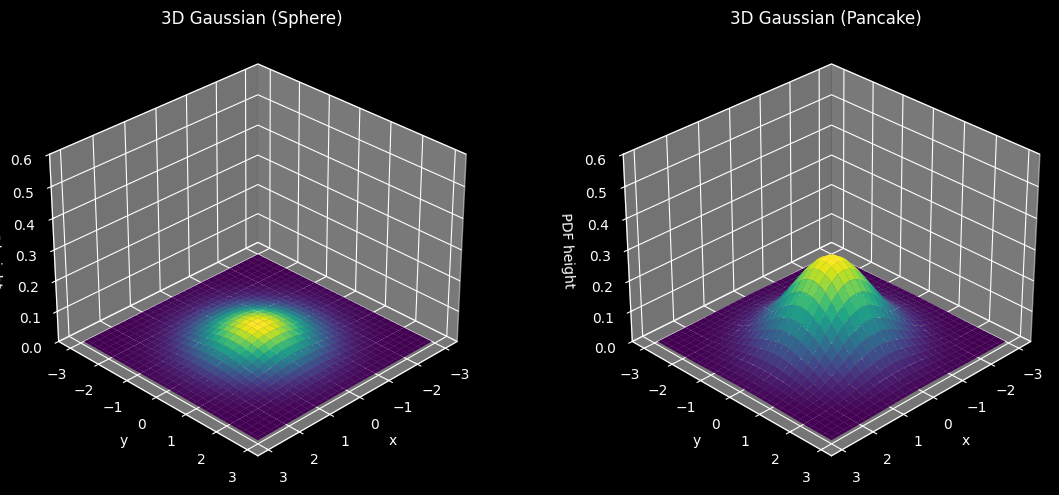

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from mpl_toolkits.mplot3d import Axes3D

def plot_gaussian(ax, cov_matrix, title, alpha=1.0):
    # 3D grid (x, y)
    x, y = np.mgrid[-3:3:.1, -3:3:.1]
    z = np.zeros_like(x)  # fixed z=0 plane

    # Stack grid into positions: (x, y, z=0)
    pos = np.empty(x.shape + (3,))
    pos[:, :, 0] = x
    pos[:, :, 1] = y
    pos[:, :, 2] = 0  # z is fixed

    # Evaluate PDF at each (x, y, 0)
    mean = np.array([0, 0, 0])
    rv = multivariate_normal(mean=mean, cov=cov_matrix)
    pdf_vals = np.zeros_like(x)

    # For each z-slice, sweep along z-axis to get max density (like a ridge)
    z_sweep = np.linspace(-3, 3, 100)
    for zi in z_sweep:
        pos[:, :, 2] = zi
        pdf_vals = np.maximum(pdf_vals, rv.pdf(pos))

    # Plot the surface
    ax.plot_surface(x, y, pdf_vals, cmap='viridis', edgecolor='none', alpha=alpha)
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('PDF height')
    ax.view_init(elev=30, azim=45)
    ax.set_zlim(0, 0.6)

# Covariance matrices
cov_sphere = np.diag([1, 1, 1])         # isotropic = sphere
cov_pancake = np.diag([1, 1, 0.05])     # compressed along z = pancake

# Plot both
fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')

plot_gaussian(ax1, cov_sphere, '3D Gaussian (Sphere)')
plot_gaussian(ax2, cov_pancake, '3D Gaussian (Pancake)')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Sampling parameters
mean = np.array([0, 0, 0])
n_samples = 30000

# Covariance matrices
cov_sphere = np.diag([1.0, 1.0, 1.0])     # isotropic
cov_pancake = np.diag([1.0, 1.0, 0.05])   # squished in z

# Generate samples
samples_sphere = np.random.multivariate_normal(mean, cov_sphere, size=n_samples)
samples_pancake = np.random.multivariate_normal(mean, cov_pancake, size=n_samples)

# Plot
fig = plt.figure(figsize=(12, 6))

# Sphere
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(samples_sphere[:, 0], samples_sphere[:, 1], samples_sphere[:, 2],
            s=1, alpha=0.3, color='red')
ax1.set_title('Isotropic Gaussian (Sphere)')
ax1.set_xlim([-3, 3])
ax1.set_ylim([-3, 3])
ax1.set_zlim([-3, 3])
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')

# Pancake
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(samples_pancake[:, 0], samples_pancake[:, 1], samples_pancake[:, 2],
            s=1, alpha=0.3, color='purple')
ax2.set_title('Anisotropic Gaussian (Pancake)')
ax2.set_xlim([-3, 3])
ax2.set_ylim([-3, 3])
ax2.set_zlim([-3, 3])
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('z')

plt.tight_layout()
plt.show()